---
## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import shap
!pip install lime
import lime
import lime.lime_tabular

print('All imports OK')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2ab56a72f22082f2bba1f5523cb653eb662458547c92eb22002ac74f6d48bf88
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
All imports OK


---
## 1. Data Loading, Preprocessing & Feature Engineering

In [2]:
df = pd.read_csv('cardiovascular_diseases_processed.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (68783, 12)


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
0,50,2,168,62,110,80,1,1,0,0,1,0
1,55,1,156,85,140,90,3,1,0,0,1,1
2,52,1,165,64,130,70,3,1,0,0,0,1


In [3]:
# Outlier capping
df_clean = df.drop(columns=['AGE_GROUP'], errors='ignore').copy()
for col in ['AGE', 'HEIGHT', 'WEIGHT', 'AP_HIGH', 'AP_LOW']:
    lo, hi = df_clean[col].quantile([0.01, 0.99])
    df_clean[col] = df_clean[col].clip(lo, hi)

# Feature engineering
df_clean['BMI']            = df_clean['WEIGHT'] / (df_clean['HEIGHT'] / 100) ** 2
df_clean['PULSE_PRESSURE'] = df_clean['AP_HIGH'] - df_clean['AP_LOW']
df_clean['MAP']            = (df_clean['AP_HIGH'] + 2 * df_clean['AP_LOW']) / 3
df_clean['HYPERTENSION']   = ((df_clean['AP_HIGH'] >= 140) | (df_clean['AP_LOW'] >= 90)).astype(int)
df_clean['OBESE']          = (df_clean['BMI'] >= 30).astype(int)

X = df_clean.drop(columns=['CARDIO_DISEASE'])
y = df_clean['CARDIO_DISEASE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Train: (55026, 16) | Test: (13757, 16)


---
# MODEL 3 — Random Forest
---

## 3.1 Train & Evaluate

In [4]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12,
    min_samples_split=10, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, rf_pred):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, rf_prob):.4f}')
print(classification_report(y_test, rf_pred, target_names=['No Disease', 'Disease']))

Accuracy: 0.7294
ROC-AUC:  0.7983
              precision    recall  f1-score   support

  No Disease       0.71      0.78      0.74      6949
     Disease       0.75      0.68      0.71      6808

    accuracy                           0.73     13757
   macro avg       0.73      0.73      0.73     13757
weighted avg       0.73      0.73      0.73     13757



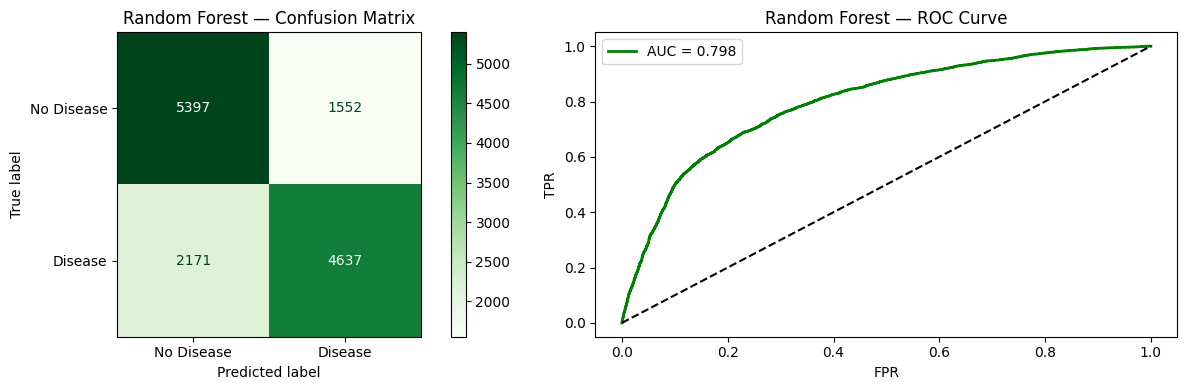

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=['No Disease', 'Disease'], cmap='Greens', ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, rf_prob)
axes[1].plot(fpr, tpr, color='green', lw=2, label=f'AUC = {roc_auc_score(y_test, rf_prob):.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Random Forest — ROC Curve'); axes[1].legend()

plt.tight_layout(); plt.show()

## 3.2 XAI — SHAP

SHAP values shape: (500, 16)


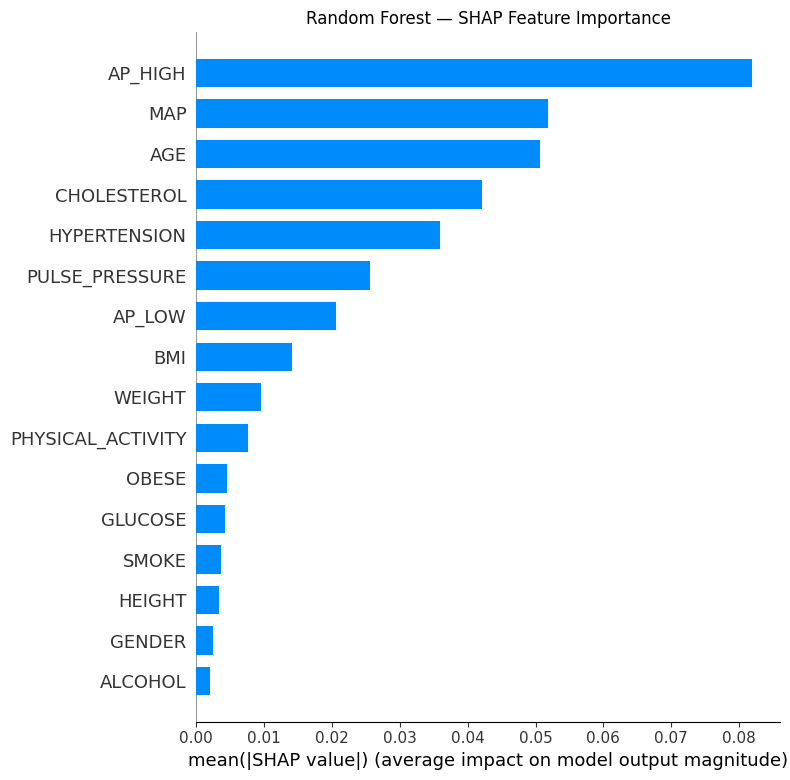

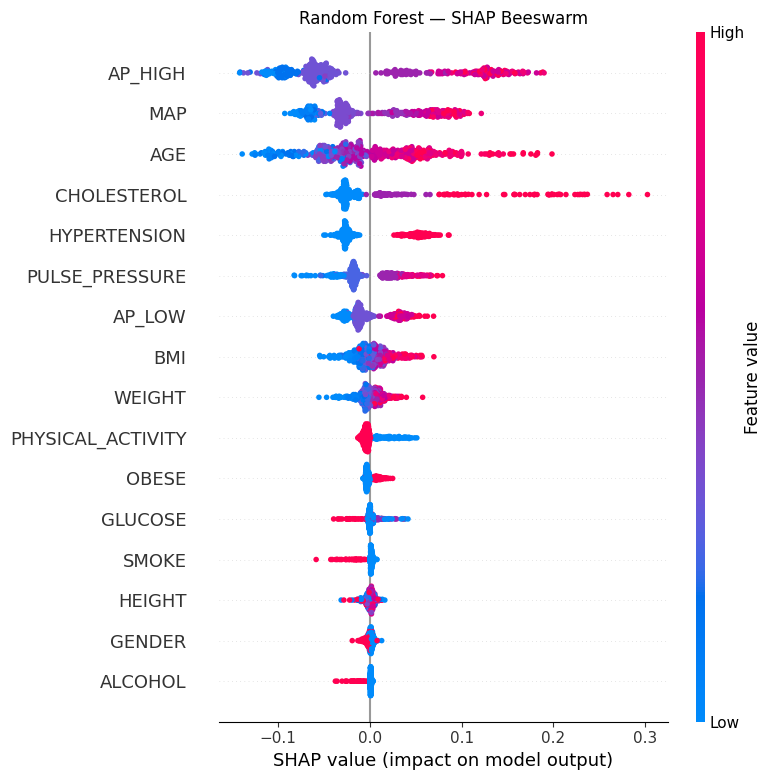

In [6]:
shap_sample_rf = X_test_scaled.sample(500, random_state=42)

explainer_rf  = shap.TreeExplainer(rf)
shap_rf_raw   = explainer_rf.shap_values(shap_sample_rf)

# Handle both old SHAP (list) and new SHAP (3D array)
if isinstance(shap_rf_raw, list):
    sv_rf = shap_rf_raw[1]
elif shap_rf_raw.ndim == 3:
    sv_rf = shap_rf_raw[:, :, 1]
else:
    sv_rf = shap_rf_raw

print(f'SHAP values shape: {sv_rf.shape}')

# Global bar
shap.summary_plot(sv_rf, shap_sample_rf, plot_type='bar', show=False)
plt.title('Random Forest — SHAP Feature Importance')
plt.tight_layout(); plt.show()

# Beeswarm
shap.summary_plot(sv_rf, shap_sample_rf, show=False)
plt.title('Random Forest — SHAP Beeswarm')
plt.tight_layout(); plt.show()

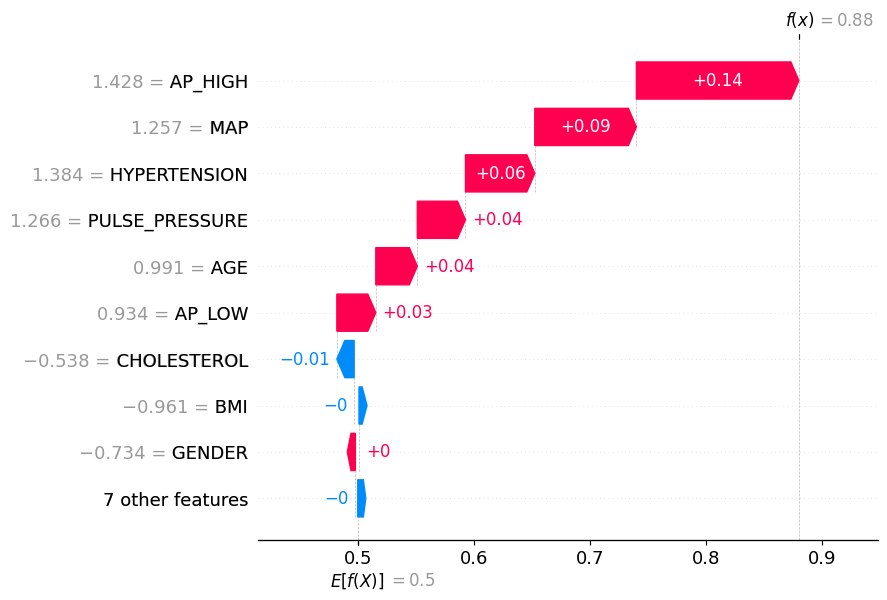

In [7]:
# Waterfall — single patient
base_val_rf = (
    explainer_rf.expected_value[1]
    if isinstance(explainer_rf.expected_value, (list, np.ndarray))
    and len(np.atleast_1d(explainer_rf.expected_value)) > 1
    else float(np.atleast_1d(explainer_rf.expected_value)[0])
)

shap.plots.waterfall(shap.Explanation(
    values        = sv_rf[0],
    base_values   = base_val_rf,
    data          = shap_sample_rf.iloc[0],
    feature_names = shap_sample_rf.columns.tolist()
))

## 3.3 XAI — LIME

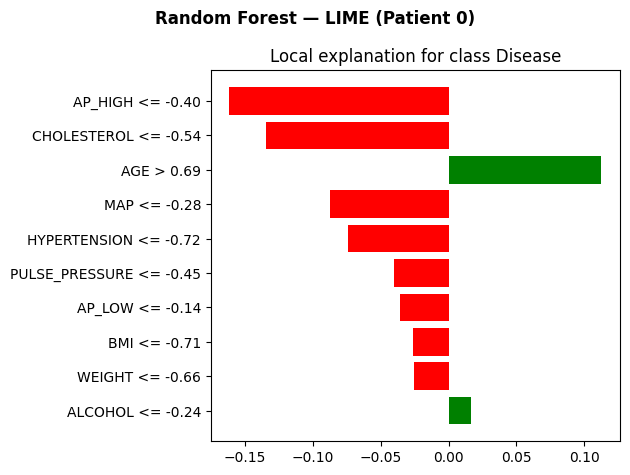

In [8]:
lime_exp_rf = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled.values,
    feature_names = X_train_scaled.columns.tolist(),
    class_names   = ['No Disease', 'Disease'],
    mode          = 'classification',
    random_state  = 42
)

exp_rf = lime_exp_rf.explain_instance(
    X_test_scaled.iloc[0].values,
    rf.predict_proba,
    num_features=10, num_samples=3000
)

fig = exp_rf.as_pyplot_figure()
fig.suptitle('Random Forest — LIME (Patient 0)', fontweight='bold')
plt.tight_layout(); plt.show()

## 3.4 XAI — PDP

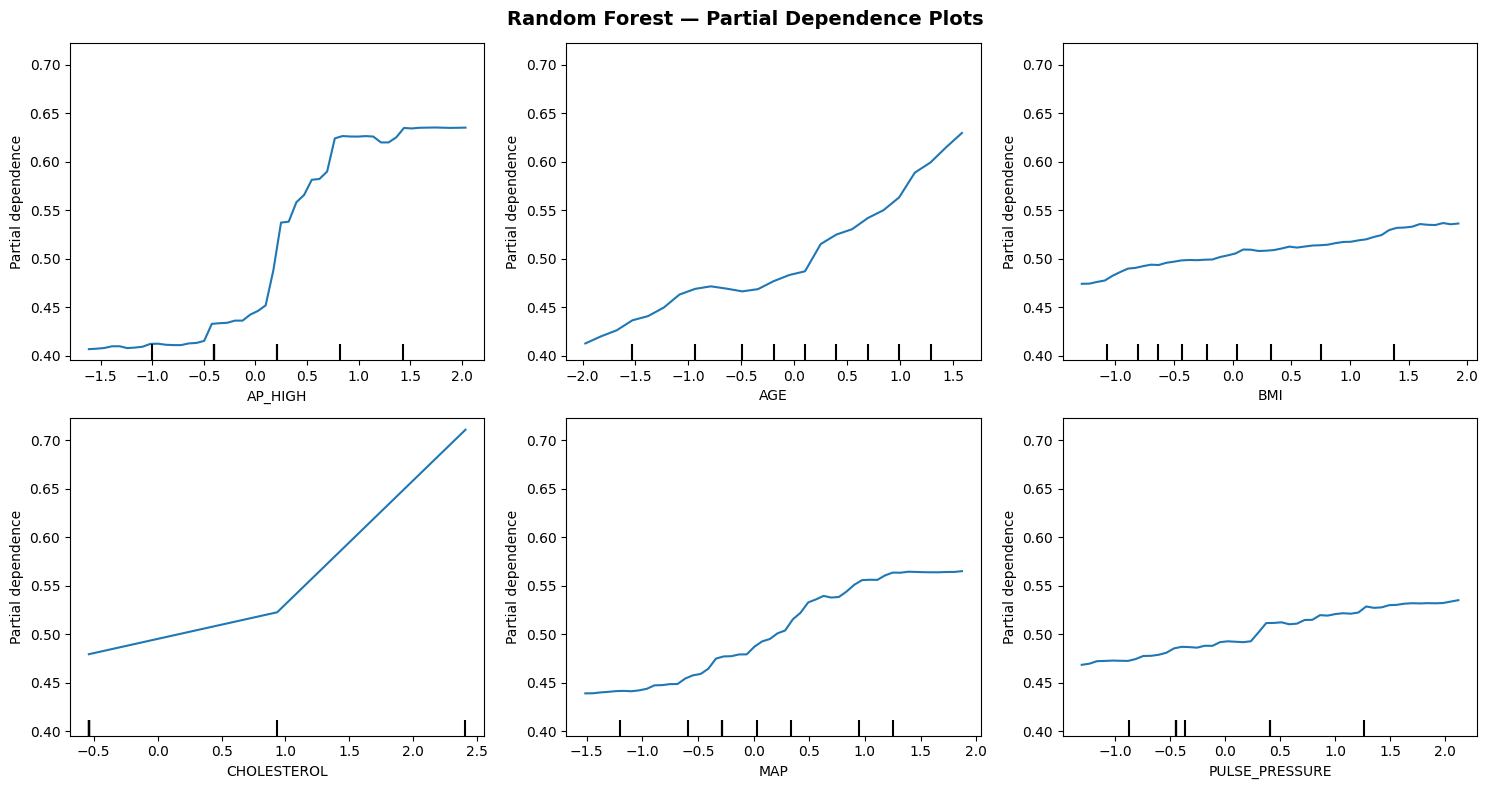

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
PartialDependenceDisplay.from_estimator(
    rf, X_test_scaled,
    features        = ['AP_HIGH', 'AGE', 'BMI', 'CHOLESTEROL', 'MAP', 'PULSE_PRESSURE'],
    kind            = 'average',
    grid_resolution = 50,
    ax              = axes.ravel(),
    n_jobs          = -1
)
fig.suptitle('Random Forest — Partial Dependence Plots', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 3.5 XAI — Permutation Importance

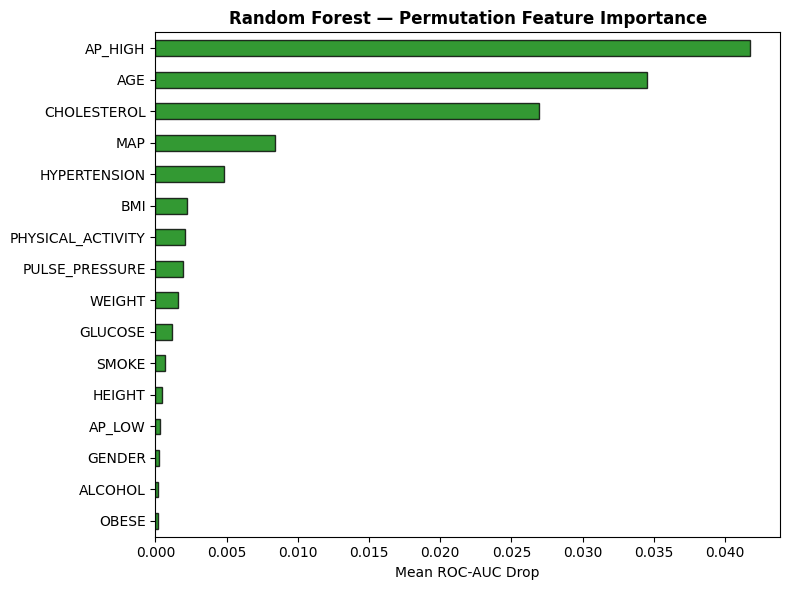

In [10]:
perm_rf = permutation_importance(
    rf, X_test_scaled, y_test,
    scoring='roc_auc', n_repeats=15, random_state=42, n_jobs=-1
)

perm_rf_df = pd.Series(
    perm_rf.importances_mean, index=X_test_scaled.columns
).sort_values(ascending=True)

perm_rf_df.plot(kind='barh', figsize=(8, 6), color='green', edgecolor='black', alpha=0.8)
plt.xlabel('Mean ROC-AUC Drop')
plt.title('Random Forest — Permutation Feature Importance', fontweight='bold')
plt.tight_layout(); plt.show()